### Importando bibliotecas necessárias

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.patches import Patch
import matplotlib.cm as cm

### Carregando o arquivo CSV e verificando as primeiras linhas do DataFrame

In [11]:
df = pd.read_csv('respostas_questionario.csv')
df.head()

,Carimbo de data/hora,Endereço de e-mail,"Declaração de suficiência dos esclarecimentos sobre a pesquisa:\r\nDeclaro que li as informações contidas nesse documento, fui devidamente informado(a) pelo(a) pesquisador (a) sobre os procedimentos que serão utilizados, riscos e desconfortos, benefícios, custo/reembolso dos participantes, confidencialidade da pesquisa, concordando ainda em participar da pesquisa. Foi-me garantido que posso retirar o consentimento a qualquer momento, sem qualquer penalidade ou prejuízo. Poderei consultar o pesquisador responsável (acima identificado) ou com o Comitê de Ética em Pesquisa com Seres Humanos do Campus Araguaia (CEP/ARAGUAIA), E-mail: cephumanos.cua@ufmt.br.com; Fone: (66) 3402-0744, sempre que entender necessário obter informações ou esclarecimentos sobre o projeto de pesquisa e minha participação no mesmo. Os resultados obtidos durante este estudo serão mantidos em sigilo, mas concordo que sejam divulgados em publicações científicas, desde que meus dados pessoais não sejam mencionados.","Declaro que li o Termo de Consentimento Livre e Esclarecido (TCLE) e que concordo em participar, como voluntário(a), da pesquisa descrita:","Declaro que faço parte do público alvo do estudo e contemplo todas as seguintes condições:\r\n\r\n- Assinalar ""Sim"" nas duas declarações iniciais; \r\n- Ter idade de 18 anos ou mais;\r\n- Ser discente/estudante de qualquer instituição de ensino superior na região de Barra do Garças - MT.",Qual o seu gênero?,A instituição em que você estuda é pública ou particular?,De qual área da sua instituição você pertence?,A qual curso você pertence?,Em qual semestre você está?,...,Com qual frequência você utiliza sistemas baseados em IA generativa em suas atividades acadêmicas?,"Você considera a interação IA e acadêmicos positiva, negativa ou neutra? Por quê?",Quão familiar você se considera com as capacidades da IA generativa? (0 para pouco e 5 para muito),Você acredita que o uso da IA generativa pode comprometer a autenticidade do seu trabalho acadêmico?,"Na sua experiência, a IA generativa tem sido eficiente nas suas atividades acadêmicas?","Se sim, por que você considera a IA generativa eficiente em suas atividades acadêmicas?",Você acredita que a IA generativa é melhor que os métodos tradicionais ?,"Se sim, selecione os motivos que justificam por que a IA Generativa é considerada melhor que os métodos tradicionais","No geral, como você avalia sua experiência ao utilizar ferramentas de IA generativa no ensino superior?",Você tem alguma sugestão ou comentário adicional sobre o uso de ferramentas de IA generativa na educação superior? (Resposta aberta)
0,30/07/2024 13:29:15,wesley.santos@sou.ufmt.br,"Sim, assim eu declaro.","Sim, aceito participar como voluntário na pesq...","Sim, assim eu declaro.",Masculino,Pública,Ciências Exatas e da Terra,Ciência da Computação,9º Semestre,...,Raramente,Positiva,0,Talvez,Sim,Auxilia em correções principalmente de textos,Não,NaN,Parcialmente Satisfeito,NaN
1,30/07/2024 13:34:26,evelynfelix515@gmail.com,"Sim, assim eu declaro.","Sim, aceito participar como voluntário na pesq...","Sim, assim eu declaro.",Feminino,Pública,"Linguística, Letras e Artes",Letras,5° Semestre,...,Mensalmente,Neutra. Pois otimiza tempo se você souber usar...,4,Talvez,Não,NaN,Não,NaN,Parcialmente Satisfeito,NaN
2,30/07/2024 13:38:37,nathalia.santos1@sou.ufmt.br,"Sim, assim eu declaro.","Sim, aceito participar como voluntário na pesq...","Sim, assim eu declaro.",Feminino,Pública,Ciências Exatas e da Terra,Engenharia Civil,7° Semestre,...,Raramente,"Neutra, ela auxilia para que os prazos sejam c...",1,Não,Não,NaN,Parcialmente,"Eficiência na Geração de Conteúdo, Variedade d...",Satisfeito,NaN
3,30/07/2024 13:49:30,amandabiomed2019@gmail.com,"Sim, assim eu declaro.","Sim, aceito participar como voluntário na pesq...","Sim, assim eu declaro.",Feminino,Pública,Ciências da Saúde,Biomedicina,4° Semestre,...,Semanalmente,Acredito que a característica da interação aca...,3,Si

# Análise Das Perguntas Demográficas com base nas áreas de estudo

### Área de Estudo

In [ ]:
# Dicionário para agrupar as áreas (mantendo a capitalização correta)
areas_agrupadas = {
    'Ciências Agrárias': 'Ciências Agrárias',
    'Linguística, Letras e Artes': 'Ciências Humanas e Sociais',
    'Agronomia': 'Ciências Agrárias',
    'Ciências Biológicas': 'Ciências Biológicas',
    'Ciências da Saúde': 'Ciências Biológicas',
    'Educação física': 'Ciências Biológicas',
    'Ciências Exatas e da Terra': 'Ciências Exatas e da Terra',
    'Engenharias': 'Ciências Exatas e da Terra',
    'Ciências Humanas': 'Ciências Humanas e Sociais',
    'Ciências Sociais Aplicadas': 'Ciências Humanas e Sociais',
    'Direito': 'Ciências Humanas e Sociais',
    'DIREITO': 'Ciências Humanas e Sociais',
    'Linguística, Letras e Artes': 'Ciências Humanas e Sociais'
}

# Remover espaços extras
df['De qual área da sua instituição você pertence?'] = df['De qual área da sua instituição você pertence?'].str.strip()

# Aplicar a substituição e agrupar
df['Área de Estudo Agrupada'] = df['De qual área da sua instituição você pertence?'].replace(areas_agrupadas)

# Verificar áreas não mapeadas
areas_nao_mapeadas = df[~df['De qual área da sua instituição você pertence?'].isin(areas_agrupadas.keys())]
print("Áreas não mapeadas:", areas_nao_mapeadas['De qual área da sua instituição você pertence?'].unique())

# Calcular a contagem de ocorrências de cada área de estudo agrupada
contagem_areas_agrupadas = df['Área de Estudo Agrupada'].value_counts().reset_index()

# Ajustar o nome das colunas
contagem_areas_agrupadas.columns = ['Área de Estudo Agrupada', 'Contagem']

print(contagem_areas_agrupadas)

# Total de respostas
total_respostas = contagem_areas_agrupadas['Contagem'].sum()
print(f"Total de respostas: {total_respostas}")

# Porcentagem ao lado de cada área de estudo agrupada
print("\nNúmero de respostas por área de estudo agrupada e porcentagem ao lado:")
for area, contagem in zip(contagem_areas_agrupadas['Área de Estudo Agrupada'], contagem_areas_agrupadas['Contagem']):
    porcentagem = (contagem / contagem_areas_agrupadas['Contagem'].sum()) * 100
    print(f"{area}: {contagem} ({porcentagem:.1f}%)")

Áreas não mapeadas: []
      Área de Estudo Agrupada  Contagem
0  Ciências Humanas e Sociais        49
1  Ciências Exatas e da Terra        28
2         Ciências Biológicas        24
3           Ciências Agrárias        22
Total de respostas: 123

Número de respostas por área de estudo agrupada e porcentagem ao lado:
Ciências Humanas e Sociais: 49 (39.8%)
Ciências Exatas e da Terra: 28 (22.8%)
Ciências Biológicas: 24 (19.5%)
Ciências Agrárias: 22 (17.9%)


### Área de Estudo

C:\Users\Luise\AppData\Local\Temp\ipykernel_12424\1223255455.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  viridis = cm.get_cmap('viridis')


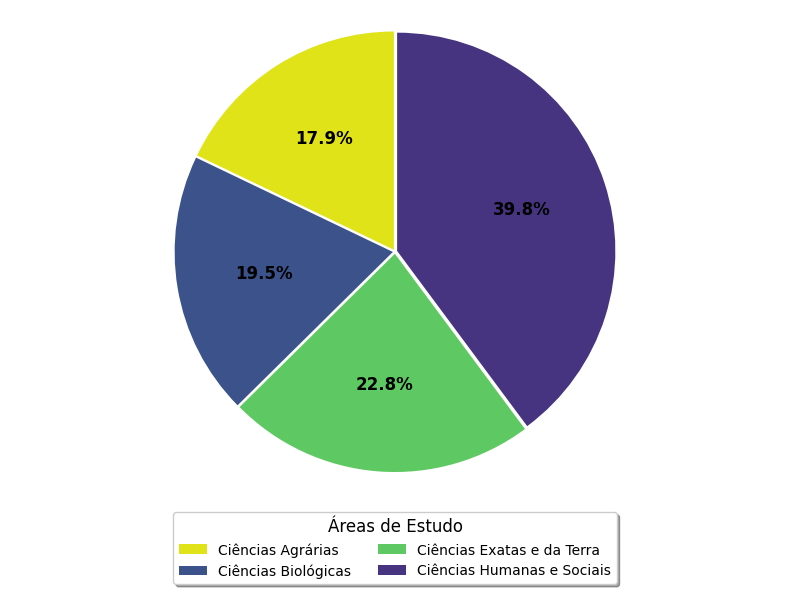

In [50]:
# Agrupar os dados por 'Área de Estudo Agrupada' e calcular a contagem total
df_grouped_areas = df.groupby('Área de Estudo Agrupada').size().reset_index(name='Contagem')

# Extrair os dados para o gráfico
labels = df_grouped_areas['Área de Estudo Agrupada']  # Nomes das áreas agrupadas
sizes = df_grouped_areas['Contagem'] / df_grouped_areas['Contagem'].sum() * 100  # Porcentagens

# Especificar cores da paleta viridis
viridis = cm.get_cmap('viridis')
colors = [viridis(0.95), viridis(0.25), viridis(0.75), viridis(0.15)]  # Valores específicos da paleta

# Criar o gráfico de pizza
fig, ax = plt.subplots(figsize=(8, 6))
wedges, texts, autotexts = ax.pie(
    sizes, 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=colors,
    # espaço entre todas as fatias
    explode=(0.01,) * len(sizes),
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)

# Personalizar os textos das porcentagens
for autotext in autotexts:
    autotext.set_color('black')  # Cor do texto
    autotext.set_fontsize(12)    # Tamanho da fonte
    autotext.set_fontweight('bold')  # Negrito

# Adicionar uma legenda
ax.legend(
    labels,
    loc='lower center', 
    bbox_to_anchor=(0.5, -0.2), 
    ncol=2, 
    title='Áreas de Estudo', 
    title_fontsize=12, 
    fontsize=10,
    fancybox=True,
    shadow=True
)

# Garantir que o gráfico seja circular
ax.axis('equal')

# Exibir o gráfico
plt.tight_layout()
plt.show()

### Gênero

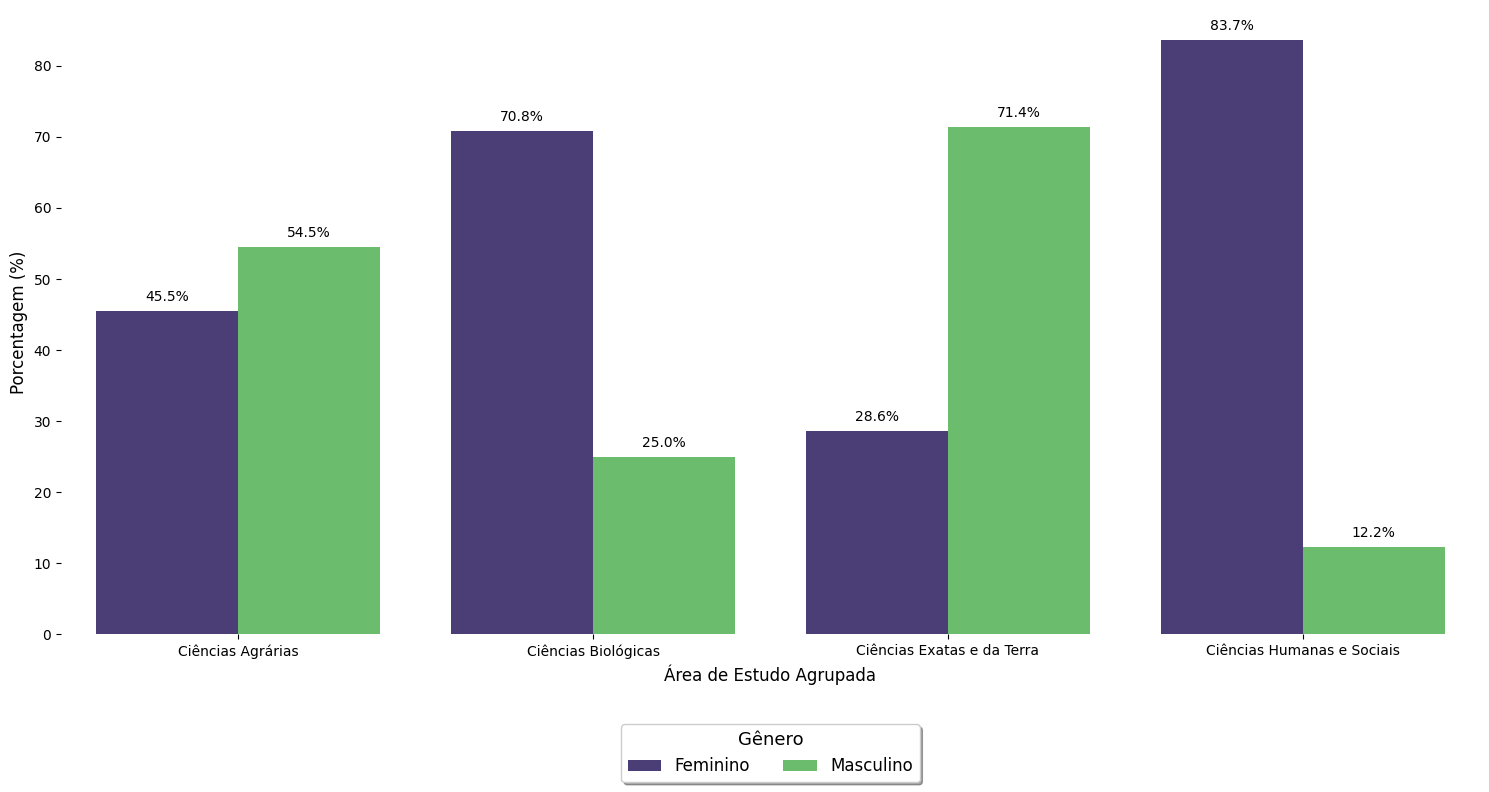

In [41]:
# Agrupar os dados por 'Área de Estudo Agrupada' e 'Gênero', calculando a contagem
df_grouped = df.groupby(['Área de Estudo Agrupada', 'Qual o seu gênero?']).size().reset_index(name='Contagem')

# Calcular a porcentagem de cada gênero dentro de cada área de estudo
df_grouped['Total_Area'] = df_grouped.groupby('Área de Estudo Agrupada')['Contagem'].transform('sum')
df_grouped['Percentual'] = (df_grouped['Contagem'] / df_grouped['Total_Area']) * 100

# Filtrar os dados para remover combinações com contagem zero
df_grouped = df_grouped[df_grouped['Contagem'] > 0]

# Ordenar os valores de 'Qual o seu gênero' para garantir a ordem correta na legenda
df_grouped['Qual o seu gênero?'] = pd.Categorical(
    df_grouped['Qual o seu gênero?'],
    categories=['Feminino', 'Masculino'],
    ordered=True
)

# Definir cores da paleta viridis
# Cores para Feminino, Masculino e Prefiro não dizer
viridis = plt.cm.viridis
colors = { 'Feminino': viridis(0.15), 'Masculino': viridis(0.75)}  

# Criar o gráfico de barras
plt.figure(figsize=(15, 8))
ax = sns.barplot(
    data=df_grouped, 
    x='Área de Estudo Agrupada', 
    y='Percentual', 
    hue='Qual o seu gênero?', 
    palette=colors  # Usar as cores da paleta viridis
)

# Adicionar rótulos de porcentagem acima das barras
# Adicionar os percentuais sobre as barras
for patch, row in zip(ax.patches, df_grouped.itertuples()):
    x = patch.get_x() + patch.get_width() / 2.0
    y = patch.get_height()
    if y > 0:  # Adicionar texto apenas para barras com altura maior que 0
        plt.text(x, y + 1, f'{y:.1f}%', ha='center', va='bottom', fontsize=10, color='black')



# Configurar título e rótulos dos eixos
# plt.title('Porcentagem de Gêneros por Área de Estudo Agrupada', fontsize=16, fontweight='bold')
plt.xlabel('Área de Estudo Agrupada', fontsize=12)
plt.ylabel('Porcentagem (%)', fontsize=12)


legend_elements = [
    Patch(facecolor=colors['Feminino'], label='Feminino'),  # Cor para Feminino
    Patch(facecolor=colors['Masculino'], label='Masculino')  # Cor para Masculino
]

# Ajustar a legenda
plt.legend(
    title='Gênero', 
    loc='lower center',
    bbox_to_anchor=(0.5, -0.25),
    ncol=2,
    fancybox=True,
    shadow=True, 
    fontsize=12, 
    title_fontsize=13)

# Ajustar layout
plt.tight_layout()

# Retirar o box
plt.box(False)
plt.grid(False)

# Exibir o gráfico
plt.show()

### Instituição (Pública ou Privada)

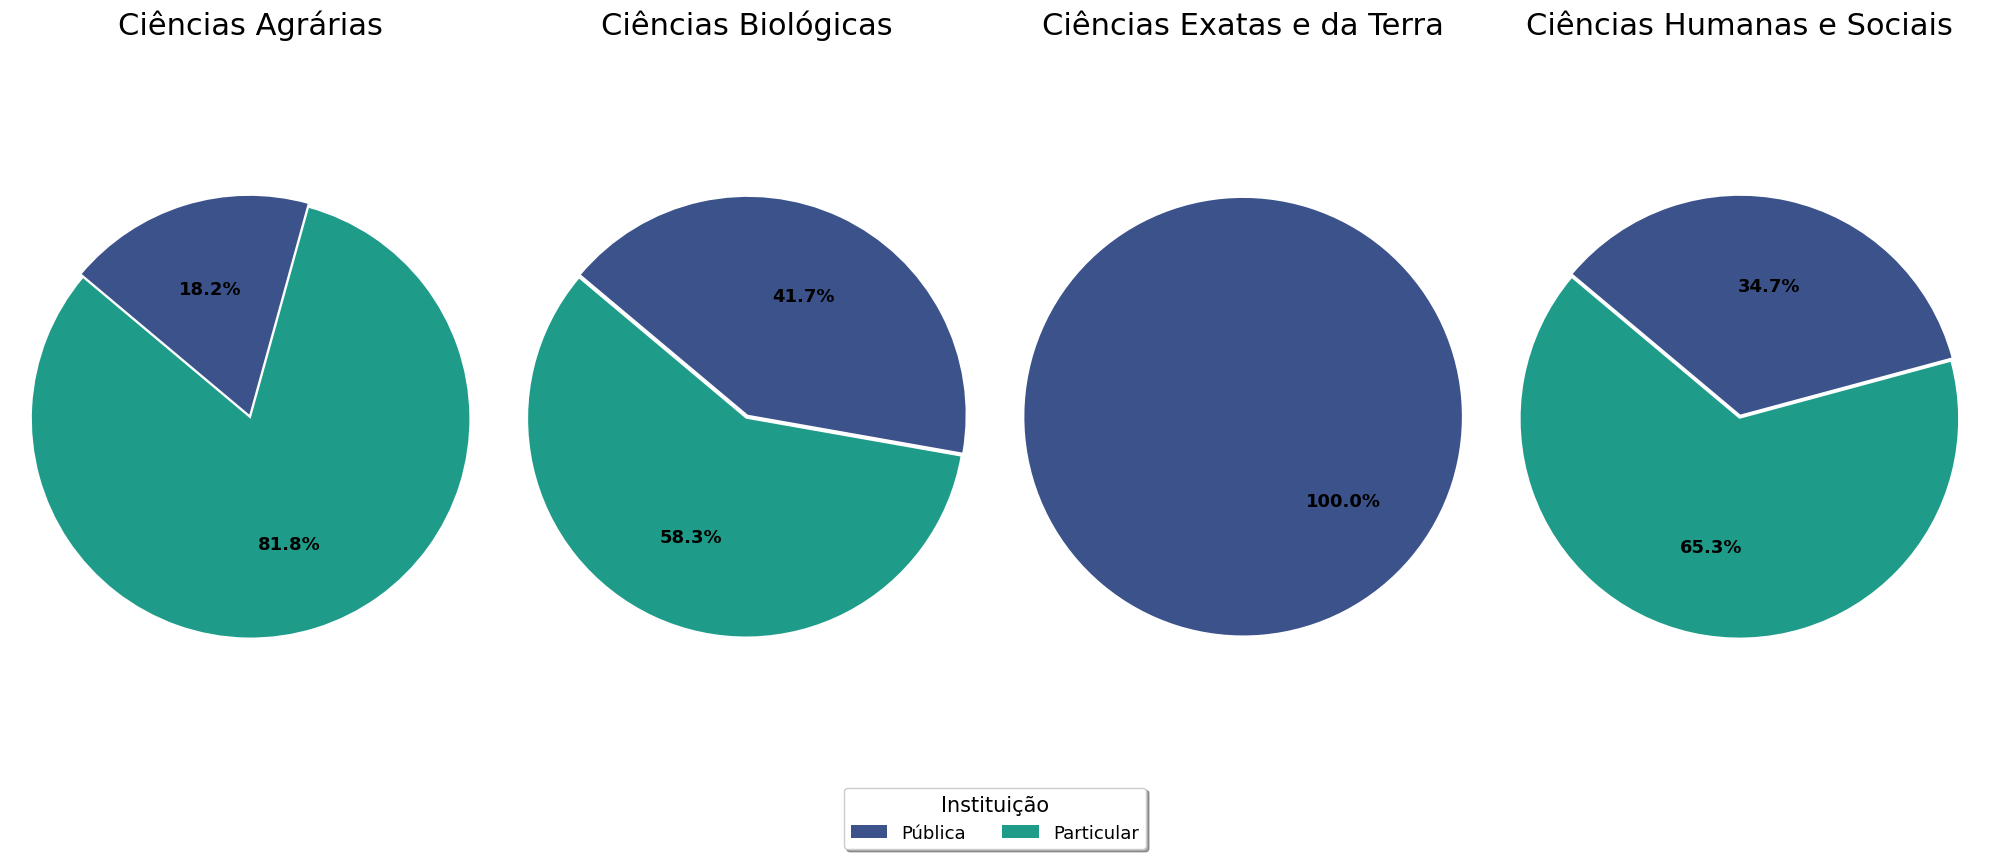

In [49]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
import pandas as pd

# Agrupar os dados
df_grouped_instituicao = df.groupby(['Área de Estudo Agrupada', 'A instituição em que você estuda é pública ou particular?']).size().reset_index(name='Contagem')
df_grouped_instituicao['Total_Area'] = df_grouped_instituicao.groupby('Área de Estudo Agrupada')['Contagem'].transform('sum')
df_grouped_instituicao['Percentual'] = (df_grouped_instituicao['Contagem'] / df_grouped_instituicao['Total_Area']) * 100
df_grouped_instituicao = df_grouped_instituicao[df_grouped_instituicao['Contagem'] > 0]

# Ordenar os valores para a legenda
df_grouped_instituicao['A instituição em que você estuda é pública ou particular?'] = pd.Categorical(
    df_grouped_instituicao['A instituição em que você estuda é pública ou particular?'],
    categories=['Pública', 'Particular'],
    ordered=True
)

# Definir cores
viridis = plt.cm.viridis
colors_instituicao = {'Pública': viridis(0.25), 'Particular': viridis(0.55)}

# Criar os gráficos de pizza lado a lado
areas_unicas = df_grouped_instituicao['Área de Estudo Agrupada'].unique()
fig, axes = plt.subplots(1, len(areas_unicas), figsize=(20, 8))

for ax, area in zip(axes, areas_unicas):
    dados_area = df_grouped_instituicao[df_grouped_instituicao['Área de Estudo Agrupada'] == area]

    # Pizza
    wedges, texts, autotexts = ax.pie(
        dados_area['Percentual'], 
        labels=None,  # Remove os labels ao lado da pizza
        autopct='%1.1f%%',
        startangle=140,
        colors=[colors_instituicao[tipo] for tipo in dados_area['A instituição em que você estuda é pública ou particular?']],
        # coloca um espaço entre as fatias
        explode=(0.01,) * len(dados_area),
        textprops={'fontsize': 12, 'fontweight': 'bold'}
    )

    # Estética dos textos
    for autotext in autotexts:
        autotext.set_fontsize(13)
        autotext.set_fontweight('bold')

    # Título centralizado para cada gráfico
    ax.set_title(area, fontsize=22, pad=15)
    ax.axis('equal')

# Legenda fora do gráfico
legend_elements = [
    Patch(facecolor=colors_instituicao['Pública'], label='Pública'),
    Patch(facecolor=colors_instituicao['Particular'], label='Particular')
]

fig.legend(
    handles=legend_elements,
    title='Instituição',
    loc='lower center',
    bbox_to_anchor=(0.5, -0.08),
    ncol=2,
    fancybox=True,
    shadow=True,
    fontsize=13,
    title_fontsize=15
)

plt.tight_layout()
plt.show()

C:\Users\Luise\AppData\Local\Temp\ipykernel_12424\1252101941.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  viridis = cm.get_cmap('viridis', len(semestres_unicos))


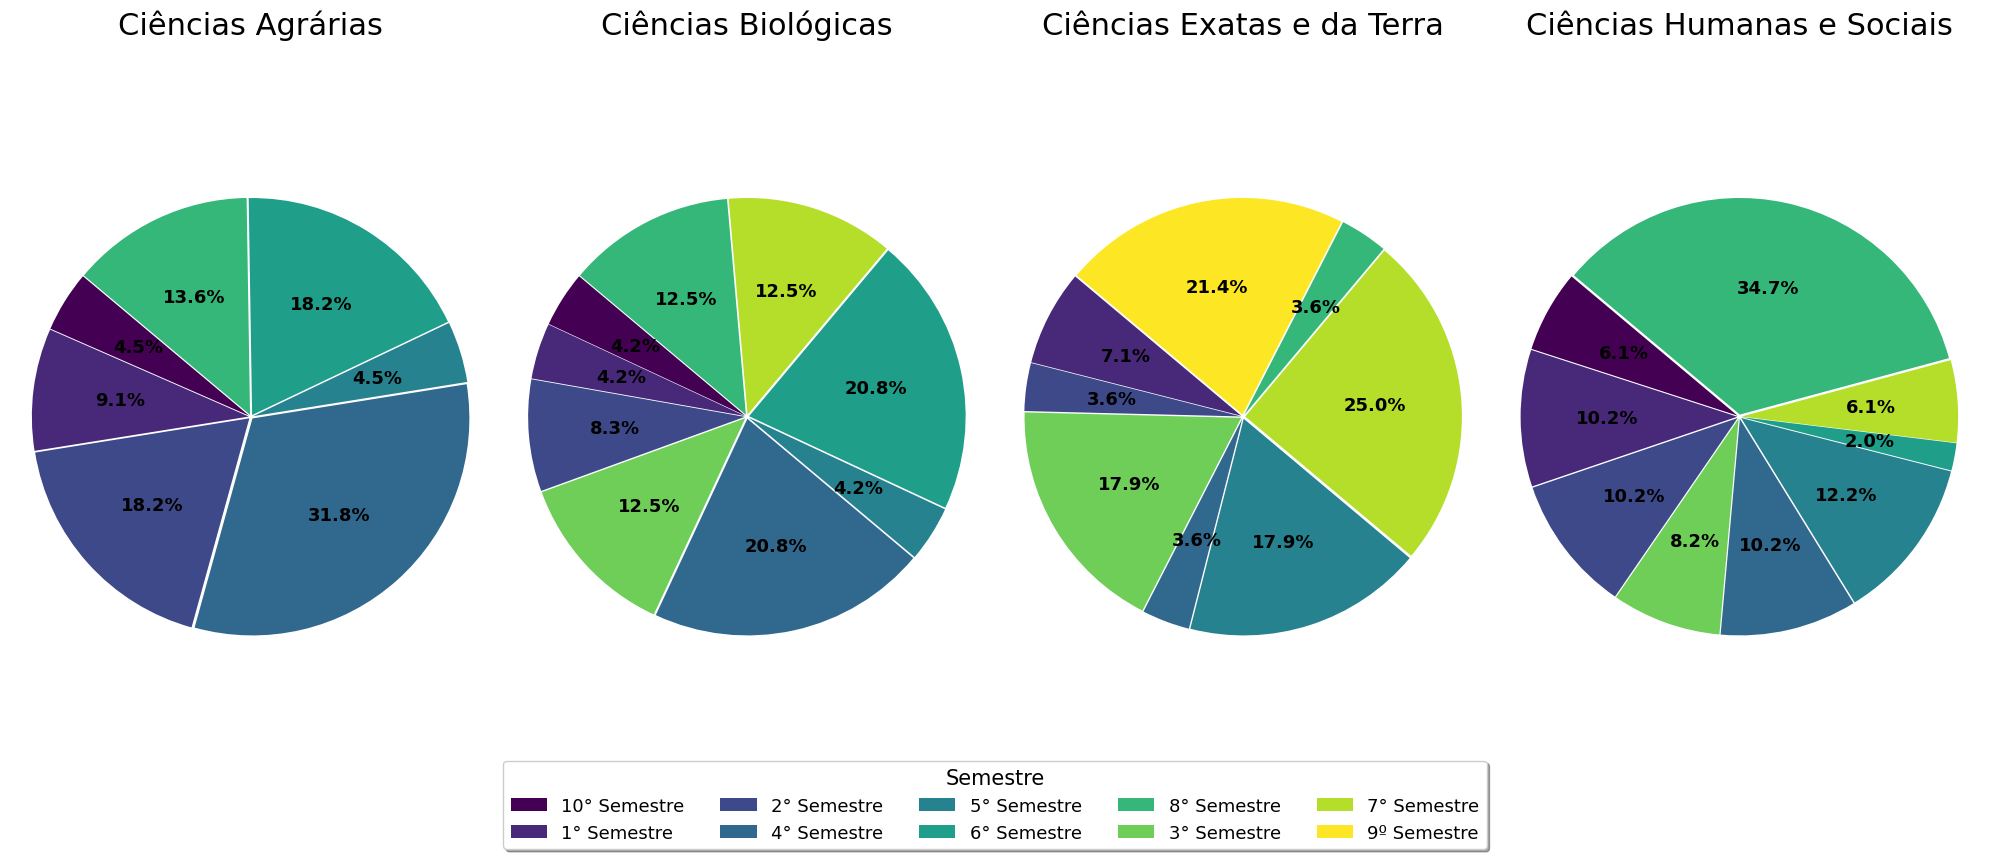

       Área de Estudo Agrupada Em qual semestre você está?  Contagem  \
0            Ciências Agrárias                10° Semestre         1   
1            Ciências Agrárias                 1° Semestre         2   
2            Ciências Agrárias                 2° Semestre         4   
3            Ciências Agrárias                 4° Semestre         7   
4            Ciências Agrárias                 5° Semestre         1   
5            Ciências Agrárias                 6° Semestre         4   
6            Ciências Agrárias                 8° Semestre         3   
7          Ciências Biológicas                10° Semestre         1   
8          Ciências Biológicas                 1° Semestre         1   
9          Ciências Biológicas                 2° Semestre         2   
10         Ciências Biológicas                 3° Semestre         3   
11         Ciências Biológicas                 4° Semestre         5   
12         Ciências Biológicas                 5° Semestre      

In [54]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.patches import Patch

# Agrupar os dados por 'Área de Estudo Agrupada' e 'Semestre', calculando a contagem
df_grouped_semestre = df.groupby(['Área de Estudo Agrupada', 'Em qual semestre você está?']).size().reset_index(name='Contagem')

# Calcular a porcentagem de cada semestre dentro de cada área de estudo
total_por_area_semestre = df_grouped_semestre.groupby('Área de Estudo Agrupada')['Contagem'].transform('sum')
df_grouped_semestre['Percentual'] = (df_grouped_semestre['Contagem'] / total_por_area_semestre) * 100

# Obter os semestres únicos
semestres_unicos = df_grouped_semestre['Em qual semestre você está?'].unique()

# Gerar cores únicas para cada semestre usando a paleta viridis
viridis = cm.get_cmap('viridis', len(semestres_unicos))
cores_semestres = {semestre: viridis(i / len(semestres_unicos)) for i, semestre in enumerate(semestres_unicos)}

# Criar os gráficos de pizza lado a lado
areas_unicas_semestre = df_grouped_semestre['Área de Estudo Agrupada'].unique()
fig, axes = plt.subplots(1, len(areas_unicas_semestre), figsize=(20, 8))

for ax, area in zip(axes, areas_unicas_semestre):
    dados_area_semestre = df_grouped_semestre[df_grouped_semestre['Área de Estudo Agrupada'] == area]

    # Obter as cores correspondentes aos semestres
    cores = [cores_semestres[semestre] for semestre in dados_area_semestre['Em qual semestre você está?']]

    # Criar o gráfico de pizza
    wedges, texts, autotexts = ax.pie(
        dados_area_semestre['Percentual'], 
        labels=None,  # Remove os labels ao lado da pizza
        autopct='%1.1f%%',
        startangle=140,
        colors=cores,  # Usar as cores únicas geradas
        explode=(0.01,) * len(dados_area_semestre),
        textprops={'fontsize': 12, 'fontweight': 'bold'}
    )

    # Estética dos textos
    for autotext in autotexts:
        autotext.set_fontsize(13)
        autotext.set_fontweight('bold')

    # Título centralizado para cada gráfico
    ax.set_title(area, fontsize=22, pad=15)
    ax.axis('equal') 

# Criar a legenda com as cores únicas
legend_elements = [
    Patch(facecolor=cores_semestres[semestre], label=f'{semestre}') for semestre in semestres_unicos
]

fig.legend(
    handles=legend_elements,
    title='Semestre',
    loc='lower center',
    bbox_to_anchor=(0.5, -0.08),
    ncol=5,
    fancybox=True,
    shadow=True,
    fontsize=13,
    title_fontsize=15
)

plt.tight_layout()
plt.show()

# imprimir os dados agrupados por semestre e área de estudo com porcentagem
print(df_grouped_semestre[['Área de Estudo Agrupada', 'Em qual semestre você está?', 'Contagem', 'Percentual']])

### Cursos

In [ ]:
# Contar o número de cursos únicos em cada área de estudo
cursos_por_area = df.groupby('Área de Estudo Agrupada')['A qual curso você pertence?'].nunique().reset_index()

# Renomear as colunas para melhor entendimento
cursos_por_area.columns = ['Área de Estudo Agrupada', 'Número de Cursos']

# Exibir o resultado
print(cursos_por_area)

# gráfico de pizza 

      Área de Estudo Agrupada  Número de Cursos
0           Ciências Agrárias                 2
1         Ciências Biológicas                10
2  Ciências Exatas e da Terra                 4
3  Ciências Humanas e Sociais                 6
